# **Insurance Prediction Project**

## loading data & Importing libraries

In [50]:
import pandas as pd
import numpy as np

insurance =pd.read_csv("/content/archive (1) (1).zip")

In [51]:
insurance


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### **Data Exploration**


In [52]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
insurance.shape

(1338, 7)

In [54]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [55]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## **data preperation**

### Data seperation as X and Y

In [56]:
Y = insurance['charges']
Y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [57]:
X = insurance.drop('charges', axis = 1)
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


## **Data Splitting**

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=100)

In [59]:
X_train

,age,sex,bmi,children,smoker,region
1306,29,female,21.850,0,yes,northeast
124,47,female,33.915,3,no,northwest
588,61,female,35.910,0,no,northeast
1127,35,female,35.860,2,no,southeast
201,48,female,32.230,1,no,southeast
...,...,...,...,...,...,...
802,21,male,22.300,1,no,southwest
53,36,male,34.430,0,yes,southeast
350,57,female,23.180,0,no,northwest
79,41,female,32.965,0,no,northwest


In [60]:
X_test

,age,sex,bmi,children,smoker,region
12,23,male,34.400,0,no,southwest
306,28,female,27.500,2,no,southwest
318,44,female,27.645,0,no,northwest
815,20,female,31.460,0,no,southeast
157,18,male,25.175,0,yes,northeast
...,...,...,...,...,...,...
713,20,male,40.470,0,no,northeast
1282,18,female,21.660,0,yes,northeast
531,62,female,31.730,0,no,northeast
537,46,female,30.200,2,no,southwest


In [61]:
Y_test

,charges
12,1826.84300
306,20177.67113
318,7421.19455
815,1877.92940
157,15518.18025
...,...
713,1984.45330
1282,14283.45940
531,14043.47670
537,8825.08600


In [62]:
Y_train

,charges
1306,16115.30450
124,10115.00885
588,13635.63790
1127,5836.52040
201,8871.15170
...,...
802,2103.08000
53,37742.57570
350,11830.60720
79,6571.02435


### **Data Preprocessing**

### **Handling Missing Values**

In [63]:
print(insurance.isnull().sum())

insurance["bmi"] = insurance["bmi"].fillna(insurance["bmi"].median())

insurance["region"] = insurance["region"].fillna(insurance["region"].mode()[0])

print(insurance.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### **Removing Duplicate Rows**

In [64]:
print(insurance.duplicated().sum())

insurance.drop_duplicates(inplace=True)

print(insurance.duplicated().sum())

1
0


### **Correcting Data Types**

In [65]:
insurance["age"] = pd.to_numeric(insurance["age"], errors="coerce")
insurance["bmi"] = pd.to_numeric(insurance["bmi"], errors="coerce")
insurance["children"] = pd.to_numeric(insurance["children"], errors="coerce")
insurance["charges"] = pd.to_numeric(insurance["charges"], errors="coerce")

### **Cleaning and Standardizing text values**

In [66]:
insurance["sex"] = insurance["sex"].str.strip().str.lower()

insurance["smoker"] = insurance["smoker"].str.strip().str.lower()

insurance["region"] = insurance["region"].str.strip().str.lower()

### **Checking invalid values**

In [82]:
print(insurance[insurance["age"] < 0])

print(insurance[insurance["bmi"] < 0])

print(insurance[insurance["charges"] < 0])

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []


### **Checking outliers**

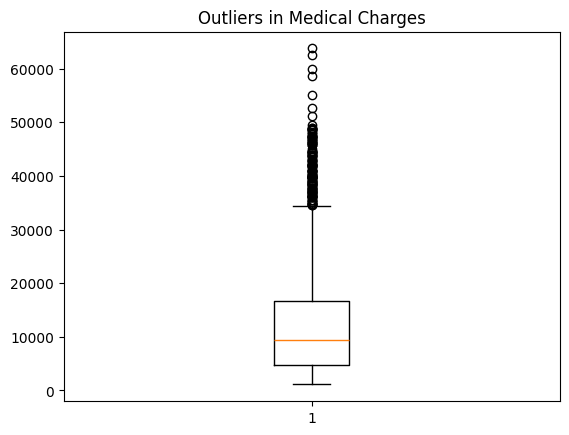

In [84]:
plt.boxplot(insurance["charges"])

plt.title("Outliers in Medical Charges")

plt.show()

## **Model Building**

### Linear Regression

**training the model & fixing assigned values**

In [67]:
from sklearn.linear_model import LinearRegression
import pandas as pd


categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

all_columns = list(set(X_train_processed.columns) | set(X_test_processed.columns))

X_train_processed = X_train_processed.reindex(columns=all_columns, fill_value=0)
X_test_processed = X_test_processed.reindex(columns=all_columns, fill_value=0)

X_train_processed = X_train_processed.sort_index(axis=1)
X_test_processed = X_test_processed.sort_index(axis=1)

lr = LinearRegression()
lr.fit(X_train_processed, Y_train)

LinearRegression()

**Applying the model to make predictions**

In [68]:
Y_lr_pred = lr.predict(X_test_processed)
Y_lr_pred

array([ 4330.17451273,  4432.55841612,  8465.47285821,  2810.39744495,
       24747.75879367, 37403.10242002, 15319.02672466,  3169.5524245 ,
       29035.47580887, 16306.57125559, 15421.1671403 ,  4842.10635982,
       11658.21733242,  4788.02875951,  9297.13213704, 31471.40230089,
       11709.37232292, 12761.37377538,  6753.09758588, 18329.19870387,
       14179.20336112,  2774.48650553,  6788.28383668, 31846.26872899,
       14069.7534512 , 32662.45411967,  7088.84573603, 40042.18465154,
       31723.38002324, 13408.10246839, 18379.57715144,  2894.27342793,
       39633.08070292, 26790.11164803,  8357.95319633, 12097.63835132,
        8229.84825687, 33044.00105522,  4508.41869493, 38056.63407668,
        7649.85053217, 13076.94223178,  5354.72483531,  8268.57135329,
        1212.39885993,  5187.12819788,  5337.6275898 ,  4101.08500781,
        2704.43652827, 11043.31093975, 17283.12212187,  7297.09207344,
        5686.50726024,  8826.71245453,  6966.56343911, 13930.57537588,
      

In [69]:
Y_lr_pred_test = lr.predict(X_test_processed)
Y_lr_pred_test

array([ 4330.17451273,  4432.55841612,  8465.47285821,  2810.39744495,
       24747.75879367, 37403.10242002, 15319.02672466,  3169.5524245 ,
       29035.47580887, 16306.57125559, 15421.1671403 ,  4842.10635982,
       11658.21733242,  4788.02875951,  9297.13213704, 31471.40230089,
       11709.37232292, 12761.37377538,  6753.09758588, 18329.19870387,
       14179.20336112,  2774.48650553,  6788.28383668, 31846.26872899,
       14069.7534512 , 32662.45411967,  7088.84573603, 40042.18465154,
       31723.38002324, 13408.10246839, 18379.57715144,  2894.27342793,
       39633.08070292, 26790.11164803,  8357.95319633, 12097.63835132,
        8229.84825687, 33044.00105522,  4508.41869493, 38056.63407668,
        7649.85053217, 13076.94223178,  5354.72483531,  8268.57135329,
        1212.39885993,  5187.12819788,  5337.6275898 ,  4101.08500781,
        2704.43652827, 11043.31093975, 17283.12212187,  7297.09207344,
        5686.50726024,  8826.71245453,  6966.56343911, 13930.57537588,
      

## **Evaluate Model proformance**

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

lr_test_mse = mean_squared_error(Y_test, Y_lr_pred_test)
lr_test_r2 = r2_score(Y_test, Y_lr_pred)

In [71]:
from sklearn.metrics import mean_squared_error, r2_score

Y_lr_train_pred = lr.predict(X_train_processed)
lr_train_mse = mean_squared_error(Y_train, Y_lr_train_pred)
lr_train_r2 = r2_score(Y_train, Y_lr_train_pred)

## **Random forest**

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_processed, Y_train)

RandomForestRegressor()

In [73]:
Y_rf_train_pred = rf.predict(X_train_processed)
Y_rf_test_pred = rf.predict(X_test_processed)

In [74]:
from sklearn.metrics import mean_squared_error, r2_score

rf_test_mse = mean_squared_error(Y_test, Y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, Y_rf_test_pred)

In [75]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(Y_train, Y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, Y_rf_train_pred)

## **Data visualization of prediction results**

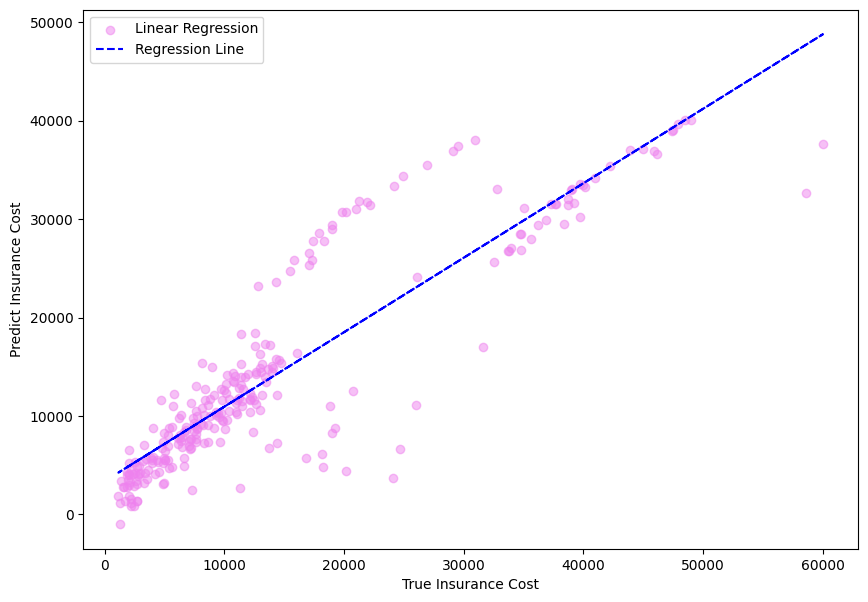

In [76]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))
plt.scatter(Y_test, Y_lr_pred_test, c='#EE82EE', label='Linear Regression', alpha=0.5)
z=np.polyfit(Y_test, Y_lr_pred_test, 1)
p=np.poly1d(z)
plt.plot(Y_test, p(Y_test), color='blue', linestyle='--', label='Regression Line')
plt.ylabel('Predict Insurance Cost')
plt.xlabel('True Insurance Cost')
plt.legend()
plt.show()

## **GRAPHS**

In [77]:
import matplotlib.pyplot as plt
import numpy as np

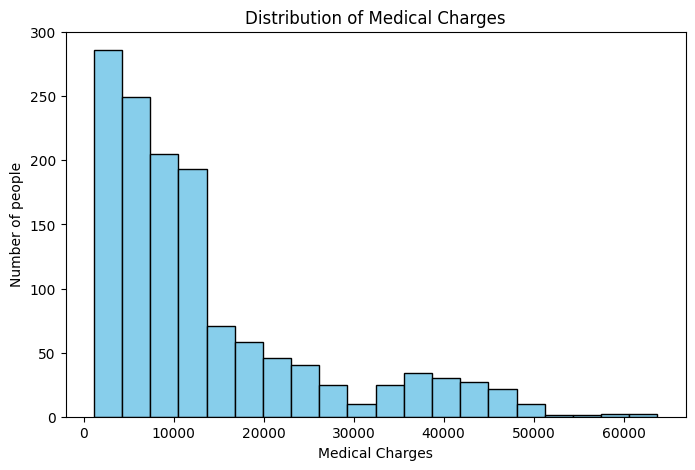

In [78]:
plt.figure(figsize = (8,5))

plt.hist(insurance["charges"], bins = 20, color = "skyblue", edgecolor = "black")

plt.title("Distribution of Medical Charges")
plt.xlabel("Medical Charges")
plt.ylabel("Number of people")

plt.show()

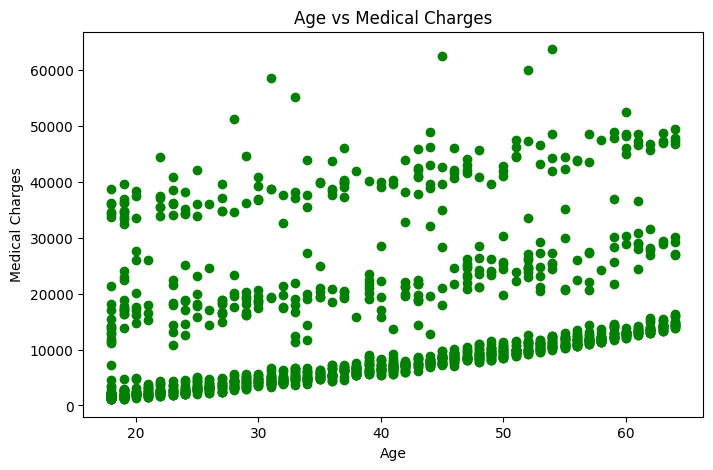

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(insurance["age"], insurance["charges"], color="green")

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.show()

Text(0, 0.5, 'Average Charges')

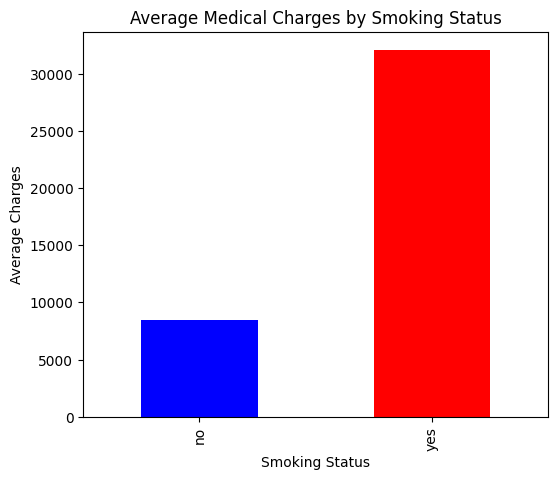

In [80]:
import matplotlib.pyplot as plt

average_charges = insurance.groupby("smoker")["charges"].mean()

plt.figure(figsize=(6,5))

average_charges.plot(kind="bar", color=["blue", "red"])

plt.title("Average Medical Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Charges")

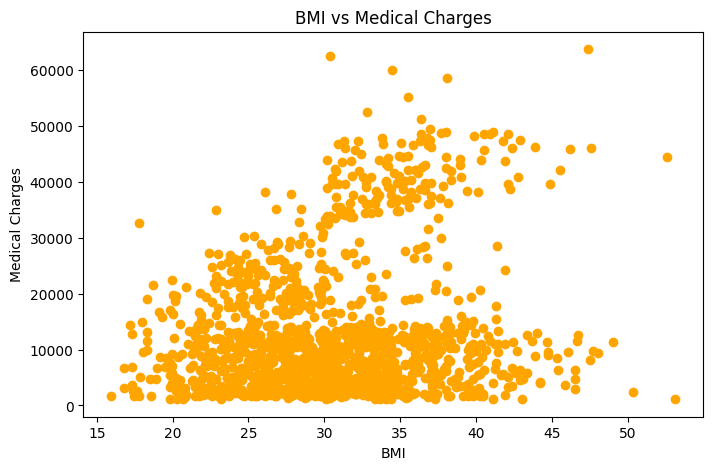

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(insurance["bmi"], insurance["charges"], color="orange")

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")

plt.show()